Este arquivo apresenta a análise exploratória do dataset Breast Cancer Wisconsin, utilizado na classificação de tumores benignos e malignos.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

RAIZ_PROJETO = Path.cwd().parent
sys.path.insert(0, str(RAIZ_PROJETO))

from src.carregar_dados import carregar_dados

sns.set_theme(style="whitegrid")

In [2]:
X, y = carregar_dados()

print(f"Registros: {X.shape[0]}")
print(f"Atributos: {X.shape[1]}")

Registros: 569
Atributos: 30


In [3]:
X.head()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [4]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   radius_mean              569 non-null    float64
 1   texture_mean             569 non-null    float64
 2   perimeter_mean           569 non-null    float64
 3   area_mean                569 non-null    float64
 4   smoothness_mean          569 non-null    float64
 5   compactness_mean         569 non-null    float64
 6   concavity_mean           569 non-null    float64
 7   concave points_mean      569 non-null    float64
 8   symmetry_mean            569 non-null    float64
 9   fractal_dimension_mean   569 non-null    float64
 10  radius_se                569 non-null    float64
 11  texture_se               569 non-null    float64
 12  perimeter_se             569 non-null    float64
 13  area_se                  569 non-null    float64
 14  smoothness_se            569 non-null

In [5]:
print("Valores ausentes:", X.isna().sum().sum())
print("Linhas duplicadas:", X.duplicated().sum())

Valores ausentes: 0
Linhas duplicadas: 0


In [6]:
distribuicao = pd.DataFrame({
    "quantidade": y.value_counts().sort_index(),
    "percentual": (
        y.value_counts(normalize=True)
        .sort_index()
        .mul(100)
        .round(2)
    ),
})

distribuicao.index = ["Benigno", "Maligno"]
distribuicao

,quantidade,percentual
Benigno,357,62.74
Maligno,212,37.26


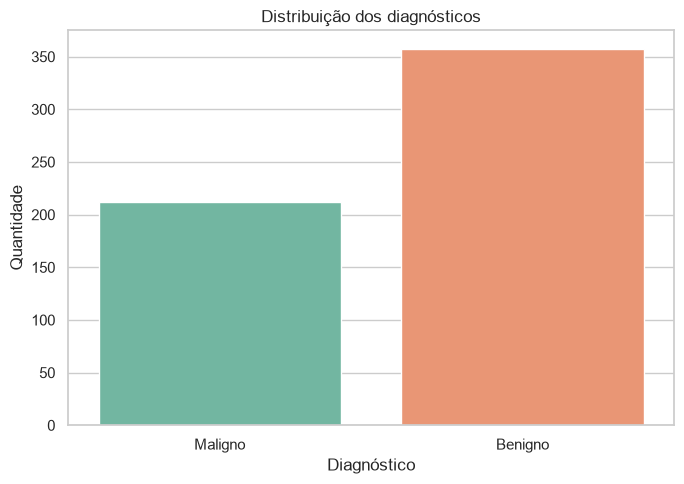

In [7]:
rotulos = y.map({
    0: "Benigno",
    1: "Maligno",
})

plt.figure(figsize=(7, 5))

sns.countplot(
    x=rotulos,
    hue=rotulos,
    palette="Set2",
    legend=False,
)

plt.title("Distribuição dos diagnósticos")
plt.xlabel("Diagnóstico")
plt.ylabel("Quantidade")
plt.tight_layout()
plt.show()

In [8]:
X.describe().T

,count,mean,std,min,25%,50%,75%,max
radius_mean,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
texture_mean,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
perimeter_mean,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
area_mean,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
smoothness_mean,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
compactness_mean,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
concavity_mean,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
concave points_mean,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
symmetry_mean,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
fractal_dimension_mean,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


In [9]:
estatisticas = X.agg(["min", "max", "mean", "std"]).T
estatisticas.sort_values("max", ascending=False)

,min,max,mean,std
area_worst,185.200000,4254.00000,880.583128,569.356993
area_mean,143.500000,2501.00000,654.889104,351.914129
area_se,6.802000,542.20000,40.337079,45.491006
perimeter_worst,50.410000,251.20000,107.261213,33.602542
perimeter_mean,43.790000,188.50000,91.969033,24.298981
texture_worst,12.020000,49.54000,25.677223,6.146258
texture_mean,9.710000,39.28000,19.289649,4.301036
radius_worst,7.930000,36.04000,16.269190,4.833242
radius_mean,6.981000,28.11000,14.127292,3.524049
perimeter_se,0.757000,21.98000,2.866059,2.021855


In [10]:
dados_correlacao = X.copy()
dados_correlacao["diagnosis"] = y

correlacoes_alvo = (
    dados_correlacao
    .corr()["diagnosis"]
    .drop("diagnosis")
    .sort_values(key=abs, ascending=False)
)

correlacoes_alvo.head(10)

concave points_worst    0.793566
perimeter_worst         0.782914
concave points_mean     0.776614
radius_worst            0.776454
perimeter_mean          0.742636
area_worst              0.733825
radius_mean             0.730029
area_mean               0.708984
concavity_mean          0.696360
concavity_worst         0.659610
Name: diagnosis, dtype: float64

Foram selecionados os 10 atributos com maior correlação, em valor absoluto, com o diagnóstico. A variável diagnosis foi codificada como 0 para benigno e 1 para maligno. Correlação positiva indica que valores maiores do atributo tendem a estar associados à classe maligna. Correlação negativa indica que valores maiores tendem a estar associados à classe benigna.

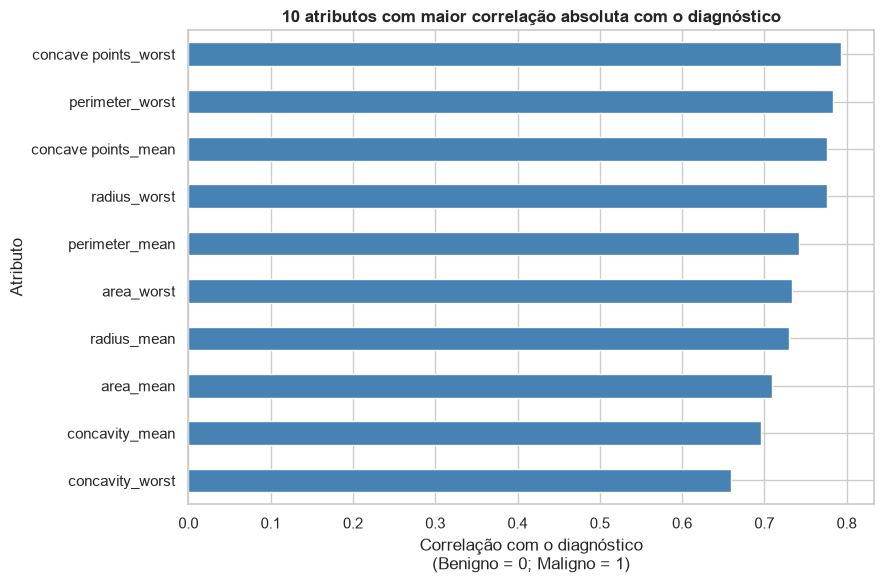

In [11]:
principais_correlacoes = correlacoes_alvo.head(10).sort_values()

plt.figure(figsize=(9, 6))

principais_correlacoes.plot(
    kind="barh",
    color="steelblue",
)

plt.title(
    "10 atributos com maior correlação absoluta com o diagnóstico",
    fontweight="bold",
)
plt.xlabel(
    "Correlação com o diagnóstico\n"
    "(Benigno = 0; Maligno = 1)"
)
plt.ylabel("Atributo")
plt.tight_layout()
plt.show()

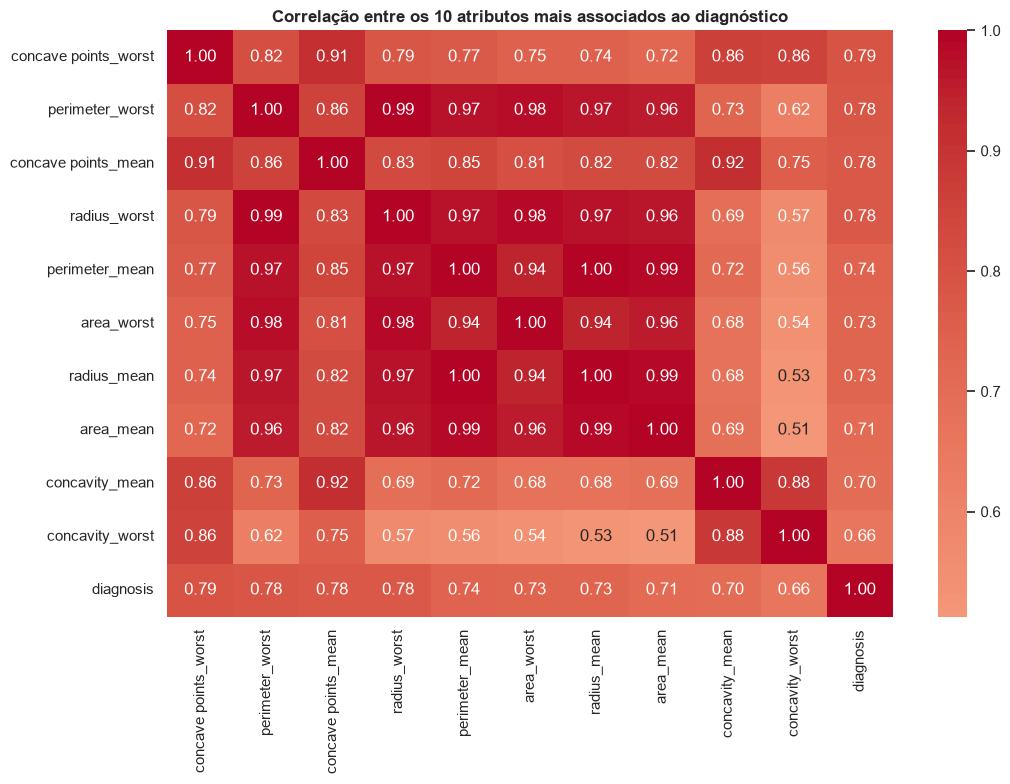

In [12]:
principais_atributos = correlacoes_alvo.head(10).index.tolist()

matriz_correlacao = dados_correlacao[
    principais_atributos + ["diagnosis"]
].corr()

plt.figure(figsize=(11, 8))

sns.heatmap(
    matriz_correlacao,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
)

plt.title(
    "Correlação entre os 10 atributos mais associados ao diagnóstico",
    fontweight="bold",
)
plt.tight_layout()
plt.show()

Conclusão ae 
- O dataset possui 569 registros e 30 atributos numéricos.
- Não foram encontrados valores ausentes nem registros duplicados.
- A classe benigna representa 62,74% dos registros e a classe maligna representa 37,26%.
- A diferença entre as classes não é extrema, mas será utilizada divisão estratificada.
- Os atributos possuem escalas bastante diferentes, justificando a normalização para KNN e SVM.
- Alguns atributos relacionados a perímetro, raio, área e pontos côncavos apresentam forte correlação com o diagnóstico.
- Todos os 30 atributos serão inicialmente mantidos para garantir uma comparação uniforme entre os modelos.